<a href="https://colab.research.google.com/github/alfisyahrin2302-horxcrux/MachineLearningDataMiningTask/blob/main/DATAMININGSENTIMEN186RAILWAY.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
pip install pandas numpy scikit-learn nltk google-play-scraper Sastrawi matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 10.4 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import re
import string
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from google_play_scraper import reviews_all, Sort
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
from google_play_scraper import reviews_all, Sort
import matplotlib.pyplot as plt
import seaborn as sns

def ambil_ulasan_168Railway():
    hasil = reviews_all(
        'com.railway168.app',
        lang='id',
        country='id',
        sort=Sort.MOST_RELEVANT
    )
    df = pd.DataFrame(hasil)
    return df[['content', 'score']]

In [17]:
ulasan_df = ambil_ulasan_168Railway()
print(f"Berhasil mengambil {len(ulasan_df)} ulasan.")

Berhasil mengambil 661 ulasan.


In [18]:
def label_sentimen(rating):
    if rating >= 4:
        return 'positif'
    elif rating == 3:
        return 'netral'
    else:
        return 'negatif'

ulasan_df['sentimen'] = ulasan_df['score'].apply(label_sentimen)
print(ulasan_df['sentimen'].value_counts())

sentimen
positif    599
negatif     39
netral      23
Name: count, dtype: int64


In [19]:
print(ulasan_df[['content', 'score', 'sentimen']])

                                               content  score sentimen
0    ini bermanfaat banget buat lihat jadwal kereta...      5  positif
1    Aplikasi yang bagus saat naik kereta ataupun h...      5  positif
2    Aplikasinya masih ada delay dan kurang akurat ...      3   netral
3    aplikasinya sudah bagus untuk para Railfans, d...      5  positif
4    mantap min aplikasi nya, gila² ini sih aplikas...      5  positif
..                                                 ...    ...      ...
656                                              good👍      5  positif
657                                         siap pakai      5  positif
658                                      saya railfans      5  positif
659                               membantuuu railfanss      5  positif
660                                        karna bagus      5  positif

[661 rows x 3 columns]


In [20]:
import re
import string
import pandas as pd
pd.set_option('display.max_colwidth', None)

def cleaning(text):
    text = re.sub(r'http\S+|www\S+', '', text) # hapus link
    text = re.sub(r'\d+', '', text) # hapus angka
    text = text.translate(str.maketrans("", "", string.punctuation)) # hapus tanda baca
    text = re.sub(r'[^\w\s]', '', text) # hapus emotikon/simbol
    return text

ulasan_df['content'] = ulasan_df['content'].fillna('')
ulasan_df['cleaning'] = ulasan_df['content'].apply(cleaning)
print(ulasan_df[['content', 'cleaning']].head())

                                                                                                                                                                                                                                                                                                                                                                                                                                               content  \
0                                                                                                                                                                                                    ini bermanfaat banget buat lihat jadwal kereta,lihat depo,rolling stock,stasiun²,serta jadwal² dinas. tapi kurang nya kadang yg di tampilkan di peta nggak pas dengan yg aslinya.kadang kelebihan kadang terlambat,jadi kurang bisa ngatur jadwal   
1                                                            Aplikasi yang bagus saat naik kereta ataupun hunting, t

In [21]:
def case_folding(text):
    return text.lower()

ulasan_df['case_folding'] = ulasan_df['cleaning'].apply(case_folding)
print(ulasan_df[['cleaning', 'case_folding']].head())

                                                                                                                                                                                                                                                                                                                                                                                                                                       cleaning  \
0                                                                                                                                                                                                    ini bermanfaat banget buat lihat jadwal keretalihat deporolling stockstasiun²serta jadwal² dinas tapi kurang nya kadang yg di tampilkan di peta nggak pas dengan yg aslinyakadang kelebihan kadang terlambatjadi kurang bisa ngatur jadwal   
1                                                                Aplikasi yang bagus saat naik kereta ataupun hunting tapi kadangk

In [22]:
from nltk.tokenize import word_tokenize
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

ulasan_df['tokenisasi'] = ulasan_df['case_folding'].apply(word_tokenize)
print(ulasan_df[['case_folding', 'tokenisasi']].head())

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


                                                                                                                                                                                                                                                                                                                                                                                                                                   case_folding  \
0                                                                                                                                                                                                    ini bermanfaat banget buat lihat jadwal keretalihat deporolling stockstasiun²serta jadwal² dinas tapi kurang nya kadang yg di tampilkan di peta nggak pas dengan yg aslinyakadang kelebihan kadang terlambatjadi kurang bisa ngatur jadwal   
1                                                                aplikasi yang bagus saat naik kereta ataupun hunting tapi kadangk

In [26]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

normal_dict = {}

def normalize(tokens):
  return [normal_dict(word) if word in normal_dict else word for word in tokens]
ulasan_df['normalisasi'] = ulasan_df['tokenisasi'].apply(normalize)
print(ulasan_df[['tokenisasi', 'normalisasi']].head())

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      tokenisasi  \
0                                                                                                                                                                                                                                    [ini, bermanfaat, banget, buat, lihat, jadwal, keretalihat, deporolling, stockstasiun²serta, jadwal², dinas, tapi, kurang, nya, kadang, yg, di, tampilkan, di, peta, nggak, pas, dengan, yg, aslinyakadang, kelebihan, kadang, terlambatjadi, kurang, bisa, ngatur, jadwal]   


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [27]:
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
factory = StopWordRemoverFactory()
stopwords = set(factory.get_stop_words())

def remove_stopwords(tokens):
    return [word for word in tokens if word not in stopwords]

ulasan_df['stopword_removed'] = ulasan_df['normalisasi'].apply(remove_stopwords)
print(ulasan_df[['normalisasi', 'stopword_removed']].head())

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     normalisasi  \
0                                                                                                                                                                                                                                    [ini, bermanfaat, banget, buat, lihat, jadwal, keretalihat, deporolling, stockstasiun²serta, jadwal², dinas, tapi, kurang, nya, kadang, yg, di, tampilkan, di, peta, nggak, pas, dengan, yg, aslinyakadang, kelebihan, kadang, terlambatjadi, kurang, bisa, ngatur, jadwal]   


In [28]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
factory = StemmerFactory()
stemmer = factory.create_stemmer()

def stemming(tokens):
    return stemmer.stem(' '.join(tokens)).split()

# Batasi data biar cepat
ulasan_df = ulasan_df.head(500)
ulasan_df['stemming'] = ulasan_df['stopword_removed'].apply(stemming)
ulasan_df['final_text'] = ulasan_df['stemming'].apply(lambda x: ' '.join(x))
print(ulasan_df[['content', 'final_text']].head())

                                                                                                                                                                                                                                                                                                                                                                                                                                               content  \
0                                                                                                                                                                                                    ini bermanfaat banget buat lihat jadwal kereta,lihat depo,rolling stock,stasiun²,serta jadwal² dinas. tapi kurang nya kadang yg di tampilkan di peta nggak pas dengan yg aslinya.kadang kelebihan kadang terlambat,jadi kurang bisa ngatur jadwal   
1                                                            Aplikasi yang bagus saat naik kereta ataupun hunting, t

In [30]:
# Feature Extraction (TF-IDF) & Persiapan Data Model
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=5000) # Ambil 5000 fitur terpenting
X = tfidf.fit_transform(ulasan_df['final_text']).toarray()
y = ulasan_df['sentimen'].values
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2, # 20% data untuk testing
    random_state=42 # Untuk hasil yang konsisten
)

In [31]:
# Pemodelan KNN & Mencari K Terbaik
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

nilai_k = [3, 5, 7, 9]
for k in nilai_k:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"K = {k}, Akurasi = {acc:.4f}")

K = 3, Akurasi = 0.8800
K = 5, Akurasi = 0.8800
K = 7, Akurasi = 0.8900
K = 9, Akurasi = 0.8900


In [32]:
# Inisialisasi model KNN dengan 9 tetangga
knn = KNeighborsClassifier(n_neighbors=9)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
akurasi = accuracy_score(y_test, y_pred)
print(f"Akurasi Model: {akurasi * 100:.2f}%")
print("\nLaporan Klasifikasi:")
print(classification_report(y_test, y_pred))

Akurasi Model: 89.00%

Laporan Klasifikasi:
              precision    recall  f1-score   support

     negatif       0.00      0.00      0.00         6
      netral       0.00      0.00      0.00         5
     positif       0.89      1.00      0.94        89

    accuracy                           0.89       100
   macro avg       0.30      0.33      0.31       100
weighted avg       0.79      0.89      0.84       100



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


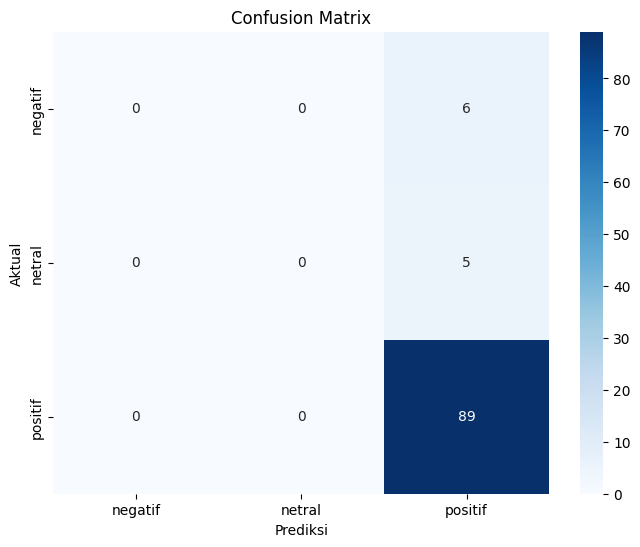

In [33]:
# Buat confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred),
            annot=True,
            cmap='Blues',
            fmt='d',
            xticklabels=['negatif', 'netral', 'positif'],
            yticklabels=['negatif', 'netral', 'positif'])
plt.title('Confusion Matrix')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

/tmp/ipykernel_4498/2859182192.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=ulasan_df, x='sentimen', palette='viridis')


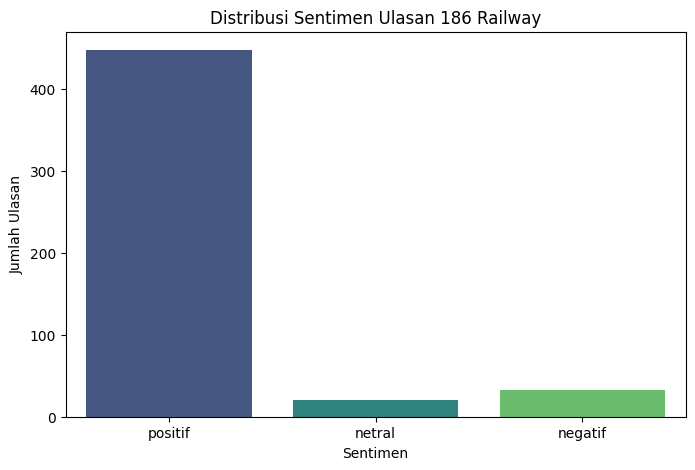

In [34]:
# Visualisasi Distribusi Sentimen
plt.figure(figsize=(8, 5))
sns.countplot(data=ulasan_df, x='sentimen', palette='viridis')
plt.title('Distribusi Sentimen Ulasan 186 Railway')
plt.xlabel('Sentimen')
plt.ylabel('Jumlah Ulasan')
plt.show()

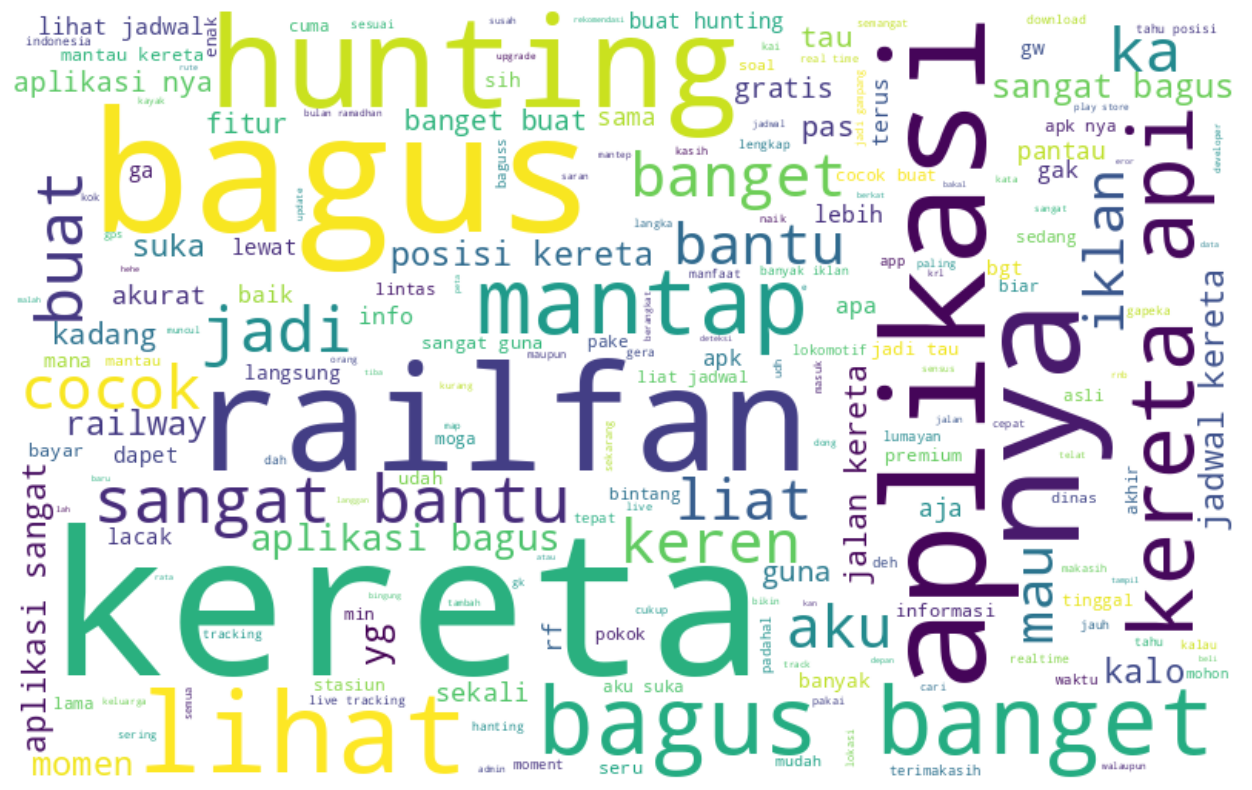

In [35]:
# Visualisasi WordCloud untuk Sentimen Positif
df_p = ulasan_df[ulasan_df['sentimen']=="positif"]
all_words_lem = ' '.join([word for word in df_p['final_text']])

%matplotlib inline
import matplotlib.pyplot as plt
from wordcloud import WordCloud

wordcloud = WordCloud(background_color='white', width=800, height=500, random_state=21, max_font_size=130).generate(all_words_lem)
plt.figure(figsize=(20, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
3plt.show()

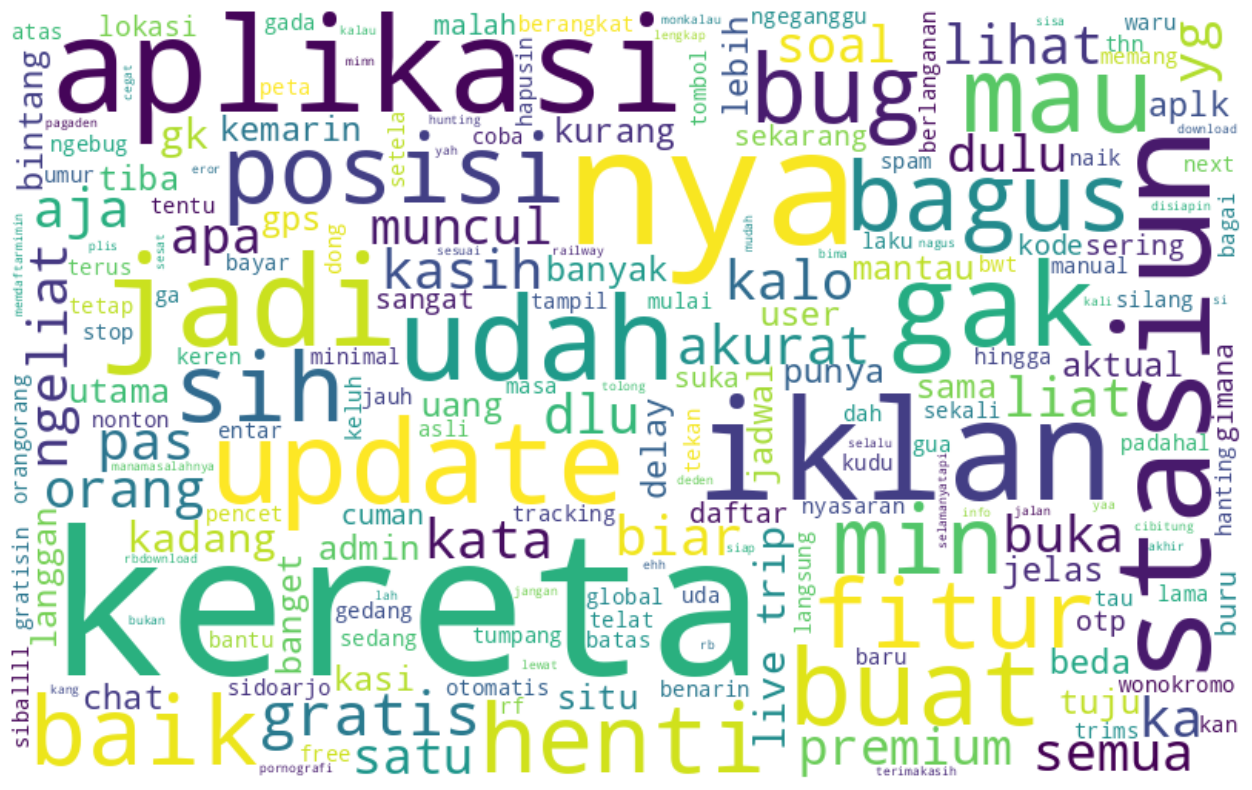

In [36]:
# Visualisasi WordCloud untuk Sentimen Netral
df_n = ulasan_df[ulasan_df['sentimen']=="netral"]
all_words_lem = ' '.join([word for word in df_n['final_text']])

%matplotlib inline
import matplotlib.pyplot as plt
from wordcloud import WordCloud

wordcloud = WordCloud(background_color='white', width=800, height=500, random_state=21, max_font_size=130).generate(all_words_lem)
plt.figure(figsize=(20, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()